# Question 1 Random Forest: Avg Trait Model

This notebook evaluates the custom CSC 466 random forest using `data/processed/breed_forest_avg.csv`.

This version replaces the individual AKC trait ratings with grouped average features: family life, physical, social, and personality. `Average Rank` is not used as a predictor.

In [1]:
from pathlib import Path
import sys

from sklearn.metrics import classification_report

for base_dir in [Path.cwd(), *Path.cwd().parents]:
    if (base_dir / "data").exists() and (base_dir / "models").exists():
        PROJECT_ROOT = base_dir
        break
else:
    raise FileNotFoundError("Could not find project root with data/ and models/ folders.")

sys.path.insert(0, str(PROJECT_ROOT))

from models.randomForest.gridSearch import build_rf, run_grid_search
from models.randomForest.rf_analysis_utils import (
    LABEL_ORDER,
    collect_split_counts,
    feature_profiles,
    load_train_test_data,
    make_prediction_results,
    plot_confusion,
)

In [2]:
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "breed_forest_avg.csv"
GRID_PATH = PROJECT_ROOT / "models" / "randomForest" / "rf_grid_search_params.csv"
PREDICTION_OUTPUT_PATH = PROJECT_ROOT / "results" / "question1" / "rf_avg_test_predictions.csv"

best_params = run_grid_search(DATA_PATH, GRID_PATH)

In [3]:
X, y, attributes, X_train, X_test, y_train, y_test = load_train_test_data(DATA_PATH)

## Final Test Results

The model is trained on the training split using the best cross-validation parameters, then evaluated on the held-out test split. Macro F1 is useful here because the three popularity tiers are not perfectly balanced.

In [4]:
best_rf = build_rf(best_params, seed=42)
best_rf.fit(X_train, y_train, attributes)
test_predictions = best_rf.predict(X_test)

## Model Interpretation

These tables show which features the forest split on most often and how average feature values differ across the actual popularity tiers.

In [5]:
split_importance = collect_split_counts(best_rf.forest)
split_importance

,Feature,Split Count
0,Family Life,63
1,Personality,63
2,Social,50
3,Physical,44


In [6]:
trait_profile, category_profile = feature_profiles(X, y, LABEL_ORDER)
trait_profile

Popularity_Tier,High Popularity,Medium Popularity,Low Popularity
Family Life,4.10,3.90,3.93
Physical,2.37,2.22,2.04
Social,3.81,3.69,3.47
Personality,3.68,3.57,3.57


In [7]:
category_profile

,Coat Type,Coat Length
Popularity_Tier,,
High Popularity,Smooth,Short
Medium Popularity,Smooth,Short
Low Popularity,Double,Medium


In [8]:
print(classification_report(y_test, test_predictions, labels=LABEL_ORDER, zero_division=0))

                   precision    recall  f1-score   support

  High Popularity       0.40      0.31      0.35        13
Medium Popularity       0.50      0.33      0.40        15
   Low Popularity       0.38      0.62      0.47        13

         accuracy                           0.41        41
        macro avg       0.43      0.42      0.41        41
     weighted avg       0.43      0.41      0.41        41



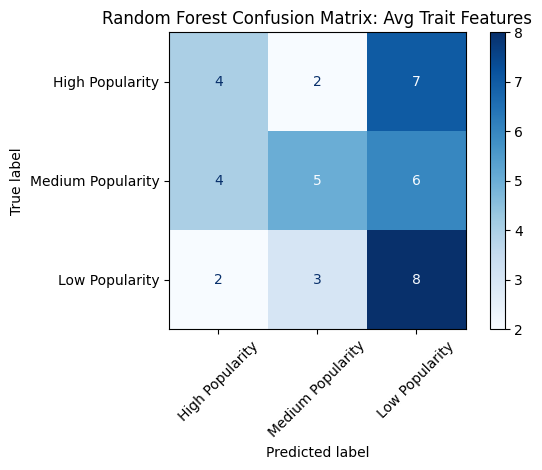

In [9]:
plot_confusion(y_test, test_predictions, "Random Forest Confusion Matrix: Avg Trait Features")

## Prediction CSV

This output compares each test-set breed's actual popularity tier to the tier predicted by the avg-trait random forest model. `Average Rank` is included for interpretation only; it is not used as a predictor.

In [10]:
PREDICTION_OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)

prediction_results = make_prediction_results(
    DATA_PATH,
    PROJECT_ROOT / "data" / "interim" / "breed_ranks.csv",
    X_test,
    y_test,
    test_predictions,
)

prediction_results.to_csv(PREDICTION_OUTPUT_PATH, index=False)
prediction_results

,Breed,Average Rank,Actual Popularity Tier,Predicted Popularity Tier,Correct
0,Bloodhound,51.2,High Popularity,Medium Popularity,False
1,Dogue de Bordeaux,73.2,Medium Popularity,Medium Popularity,True
2,Irish Water Spaniel,163.6,Low Popularity,Low Popularity,True
3,Anatolian Shepherd Dog,87.9,Medium Popularity,High Popularity,False
4,Belgian Malinoi,42.2,High Popularity,Low Popularity,False
5,Italian Greyhound,67.2,Medium Popularity,Medium Popularity,True
6,Chinese Shar-Pei,65.5,High Popularity,High Popularity,True
7,Afghan Hound,108.9,Medium Popularity,Medium Popularity,True
8,Polish Lowland Sheepdog,175.6,Low Popularity,High Popularity,False
9,Irish Terrier,124.9,Medium Popularity,Medium Popularity,True
